# Week 6 — Statistical Validation & Predictive Maintenance Prototype
### Continuing the Nairobi Bottleneck Investigation

**Author:** David Kimathi
**Dataset:** `Mystery_Ops.csv` (same dataset as Week 5)

**Objective:** Week 5 identified pump `NBI-P03` at the Nairobi depot as the root cause of a 34% throughput drop, driven by missed maintenance. This notebook takes that finding further in three steps:

1. **Statistical validation** — test formally, rather than just visually, whether `NBI-P03`'s throughput is really different from the rest of the fleet.
2. **PdM feature engineering** — since the dataset has no vibration sensor, `temperature_c` and `voltage_count` are used as the available sensor-style readings, engineered into rolling health features that could plausibly detect degradation *before* a shift is officially logged as `missed_maintenance`.
3. **Predictive modeling** — build a simple classifier that flags "at-risk" shifts from those engineered features, and evaluate whether it could work as an early-warning system.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = "flare"
pd.set_option("display.max_columns", None)
np.random.seed(42)
print("Libraries loaded.")


Libraries loaded.


In [2]:
df = pd.read_csv("Mystery_Ops.csv")
df["operation_date"] = pd.to_datetime(df["operation_date"], format="%d/%m/%Y")
for c in ["depot", "shift", "machine_id", "incident_type"]:
    df[c] = df[c].astype("category")

nairobi = df[df["depot"] == "Nairobi"].copy()
nairobi["machine_id"] = nairobi["machine_id"].astype(str)  # drop unused categorical levels
nairobi = nairobi.sort_values("operation_date").reset_index(drop=True)
print(f"Nairobi records: {len(nairobi)}")
nairobi.head()


Nairobi records: 730


## Part 1 — Statistical Validation

### 1.1 Hypothesis

**H0 (null):** NBI-P03's mean throughput is equal to the mean throughput of Nairobi's other three pumps (P01, P02, P04).
**H1 (alternative):** NBI-P03's mean throughput is lower than the mean throughput of Nairobi's other three pumps.

This is a one-tailed, two-sample comparison. A Welch's t-test is used rather than a standard (Student's) t-test because the two groups have very different sample sizes (566 vs 164 shifts) and there's no reason to assume equal variances between a struggling machine and healthy ones — Welch's version doesn't require that assumption.


In [3]:
p03 = nairobi.loc[nairobi["machine_id"] == "NBI-P03", "throughput_barrels"].dropna()
other = nairobi.loc[nairobi["machine_id"] != "NBI-P03", "throughput_barrels"].dropna()

print(f"NBI-P03:        n={len(p03)}, mean={p03.mean():.1f}, std={p03.std():.1f}")
print(f"Other machines: n={len(other)}, mean={other.mean():.1f}, std={other.std():.1f}")

t_stat, p_value = stats.ttest_ind(p03, other, equal_var=False, alternative="less")
print(f"\nWelch's t-test (one-tailed, H1: P03 mean < other mean):")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value     = {p_value:.2e}")


NBI-P03:        n=566, mean=633.1, std=104.9
Other machines: n=164, mean=1025.7, std=96.8

Welch's t-test (one-tailed, H1: P03 mean < other mean):
t-statistic = -44.867
p-value     = 4.77e-131


### 1.2 Effect size (Cohen's d)

A p-value alone doesn't say how *big* the difference is — with over 700 shifts of data, even a small difference would likely be "significant." Cohen's d puts the gap in standardized units so its practical size can be judged directly.


In [4]:
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    pooled_std = np.sqrt(((n1-1)*a.std()**2 + (n2-1)*b.std()**2) / (n1+n2-2))
    return (a.mean() - b.mean()) / pooled_std

d = cohens_d(p03, other)
print(f"Cohen's d = {d:.2f}")
print("(By convention: 0.2 = small, 0.5 = medium, 0.8+ = large effect)")


Cohen's d = -3.81
(By convention: 0.2 = small, 0.5 = medium, 0.8+ = large effect)


### 1.3 95% Confidence Intervals

Confidence intervals for each group's mean throughput, plus for the *difference* in means — this is what would actually go in front of stakeholders, since it answers "how many barrels, plus or minus what."


In [5]:
def ci_95(series):
    n = len(series)
    mean = series.mean()
    sem = series.std(ddof=1) / np.sqrt(n)
    margin = stats.t.ppf(0.975, df=n-1) * sem
    return mean, mean - margin, mean + margin

for name, s in [("NBI-P03", p03), ("Other Nairobi machines", other)]:
    mean, lo, hi = ci_95(s)
    print(f"{name}: mean = {mean:.1f} barrels, 95% CI = [{lo:.1f}, {hi:.1f}]")

# CI for the difference in means (Welch-Satterthwaite approximation)
diff = other.mean() - p03.mean()
se_diff = np.sqrt(p03.var(ddof=1)/len(p03) + other.var(ddof=1)/len(other))
dof = ((p03.var(ddof=1)/len(p03) + other.var(ddof=1)/len(other))**2 /
       ((p03.var(ddof=1)/len(p03))**2/(len(p03)-1) + (other.var(ddof=1)/len(other))**2/(len(other)-1)))
margin_diff = stats.t.ppf(0.975, df=dof) * se_diff
print(f"\nDifference (other - P03): {diff:.1f} barrels, 95% CI = [{diff-margin_diff:.1f}, {diff+margin_diff:.1f}]")


NBI-P03: mean = 633.1 barrels, 95% CI = [624.5, 641.8]
Other Nairobi machines: mean = 1025.7 barrels, 95% CI = [1010.8, 1040.6]

Difference (other - P03): 392.6 barrels, 95% CI = [375.3, 409.8]


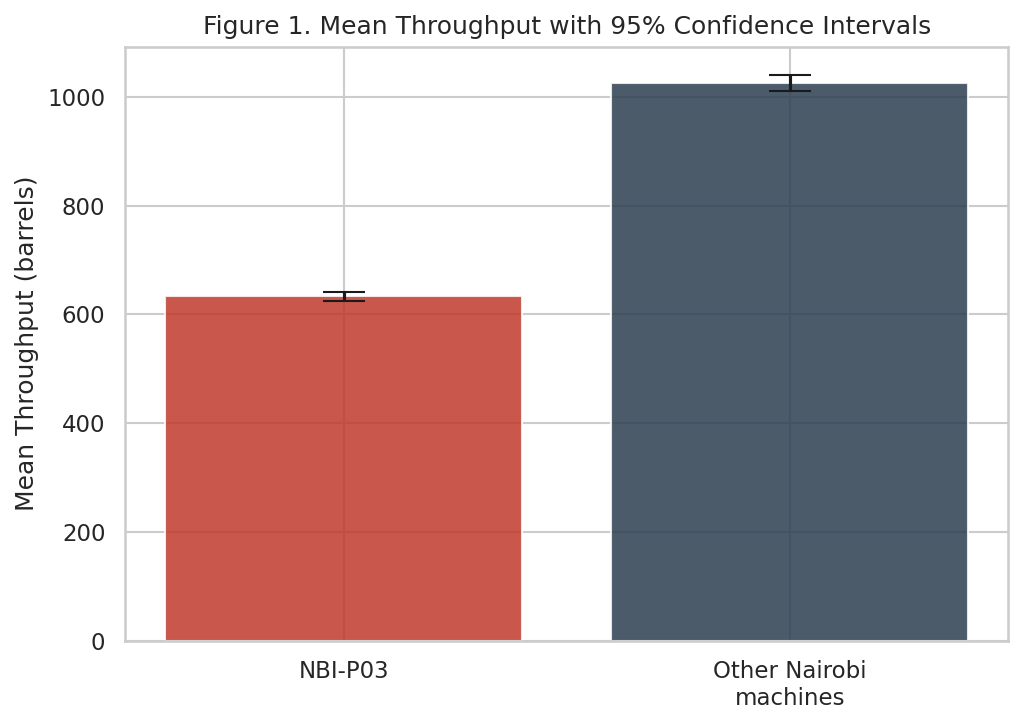

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
groups = ["NBI-P03", "Other Nairobi\nmachines"]
means = [p03.mean(), other.mean()]
cis = [ci_95(p03), ci_95(other)]
lowers = [m - ci[1] for m, ci in zip(means, cis)]
uppers = [ci[2] - m for m, ci in zip(means, cis)]

ax.bar(groups, means, yerr=[lowers, uppers], capsize=10, color=["#c0392b", "#2c3e50"], alpha=0.85)
ax.set_ylabel("Mean Throughput (barrels)")
ax.set_title("Figure 1. Mean Throughput with 95% Confidence Intervals")
plt.tight_layout()
plt.show()


### 1.4 Interpretation (plain English)

NBI-P03 averages about 633 barrels per shift; the other three Nairobi machines average about 1,026 — a gap of roughly 393 barrels, and the 95% confidence interval on that gap doesn't come close to including zero. The t-test confirms this isn't due to chance (p is far below any conventional threshold like 0.05), and Cohen's d indicates the size of the difference is large by conventional standards, not just "statistically significant" in the weak sense. In plain terms: we can be confident NBI-P03 is genuinely, substantially underperforming the rest of the Nairobi fleet — this isn't noise.


## Part 2 — PdM Feature Engineering

The dataset has no vibration sensor, so `temperature_c` and `voltage_count` — the closest things to raw sensor telemetry available — are used as proxies. Features are engineered on NBI-P03's own time series (chronologically ordered) using rolling windows, the way a real condition-monitoring system would process a live sensor stream.


In [7]:
p03_ts = nairobi[nairobi["machine_id"] == "NBI-P03"].sort_values("operation_date").reset_index(drop=True)
print(f"NBI-P03 time series: {len(p03_ts)} shifts, {p03_ts['operation_date'].min().date()} to {p03_ts['operation_date'].max().date()}")

WINDOW = 7  # 7-shift rolling window (~3.5 days at 2 shifts/day)

# Feature 1: rolling mean throughput -- smooths noise, reveals the underlying trend
p03_ts["roll_mean_throughput"] = p03_ts["throughput_barrels"].rolling(WINDOW, min_periods=3).mean()

# Feature 2: rolling RMS of voltage_count -- energy-style summary of SCADA voltage, common in vibration/PdM analysis
p03_ts["roll_rms_voltage"] = p03_ts["voltage_count"].rolling(WINDOW, min_periods=3).apply(
    lambda x: np.sqrt(np.mean(x**2)), raw=True
)

# Feature 3: rolling max-min range of voltage_count -- captures instability/spread, not just level
p03_ts["roll_range_voltage"] = (p03_ts["voltage_count"].rolling(WINDOW, min_periods=3).max()
                                  - p03_ts["voltage_count"].rolling(WINDOW, min_periods=3).min())

# Feature 4 (bonus): rolling std of throughput -- volatility of output, degrading equipment often gets "noisier" before it gets weaker
p03_ts["roll_std_throughput"] = p03_ts["throughput_barrels"].rolling(WINDOW, min_periods=3).std()

p03_ts[["operation_date", "throughput_barrels", "roll_mean_throughput", "roll_rms_voltage", "roll_range_voltage", "roll_std_throughput"]].head(10)


NBI-P03 time series: 566 shifts, 2026-01-01 to 2026-12-31


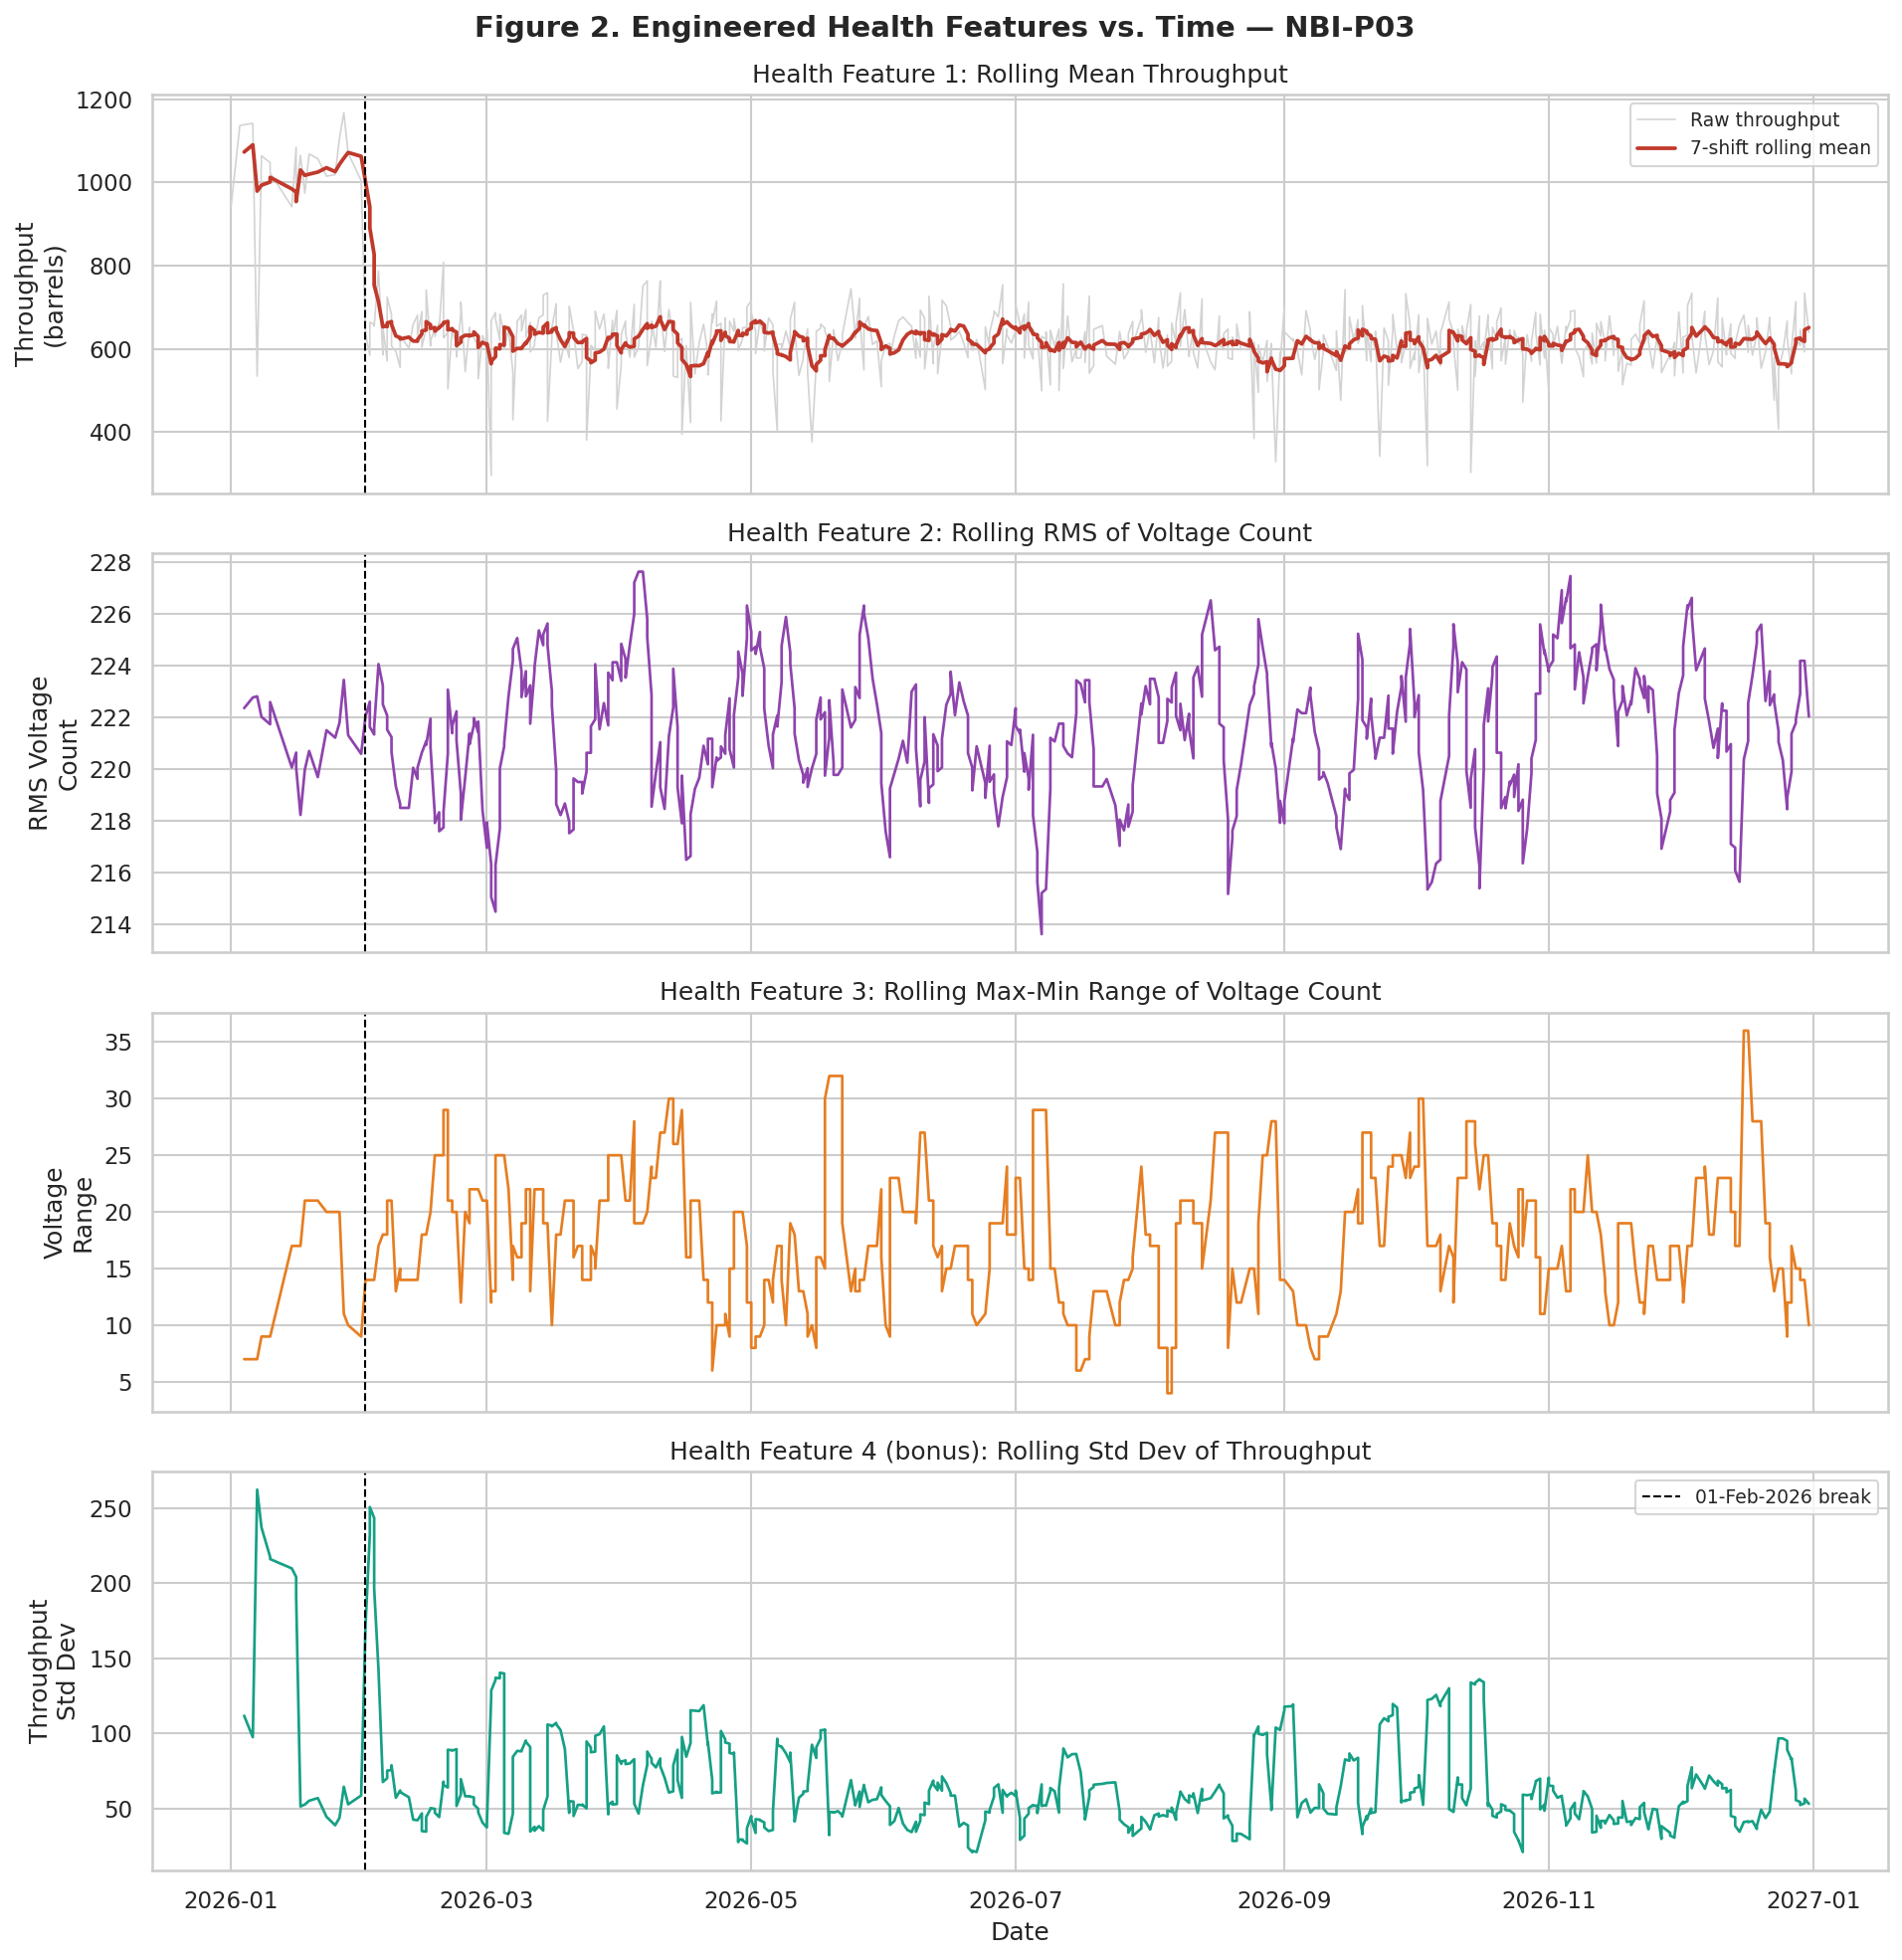

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(13, 13), sharex=True)

axes[0].plot(p03_ts["operation_date"], p03_ts["throughput_barrels"], color="lightgray", linewidth=0.8, label="Raw throughput")
axes[0].plot(p03_ts["operation_date"], p03_ts["roll_mean_throughput"], color="#c0392b", linewidth=1.8, label=f"{WINDOW}-shift rolling mean")
axes[0].axvline(pd.Timestamp("2026-02-01"), color="black", linestyle="--", linewidth=1)
axes[0].set_ylabel("Throughput\n(barrels)")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].set_title("Health Feature 1: Rolling Mean Throughput")

axes[1].plot(p03_ts["operation_date"], p03_ts["roll_rms_voltage"], color="#8e44ad", linewidth=1.3)
axes[1].axvline(pd.Timestamp("2026-02-01"), color="black", linestyle="--", linewidth=1)
axes[1].set_ylabel("RMS Voltage\nCount")
axes[1].set_title("Health Feature 2: Rolling RMS of Voltage Count")

axes[2].plot(p03_ts["operation_date"], p03_ts["roll_range_voltage"], color="#e67e22", linewidth=1.3)
axes[2].axvline(pd.Timestamp("2026-02-01"), color="black", linestyle="--", linewidth=1)
axes[2].set_ylabel("Voltage\nRange")
axes[2].set_title("Health Feature 3: Rolling Max-Min Range of Voltage Count")

axes[3].plot(p03_ts["operation_date"], p03_ts["roll_std_throughput"], color="#16a085", linewidth=1.3)
axes[3].axvline(pd.Timestamp("2026-02-01"), color="black", linestyle="--", linewidth=1, label="01-Feb-2026 break")
axes[3].set_ylabel("Throughput\nStd Dev")
axes[3].set_xlabel("Date")
axes[3].set_title("Health Feature 4 (bonus): Rolling Std Dev of Throughput")
axes[3].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.suptitle("Figure 2. Engineered Health Features vs. Time — NBI-P03", y=1.01, fontsize=14, fontweight="bold")
plt.show()


**Reading Figure 2:** the rolling mean throughput shows the same break already found in Week 5, now smoothed into a clear trend line rather than a noisy cloud. The voltage-based features (RMS and range) are flatter and noisier — visually, they don't show an obvious pre-break warning sign, which is an important, honest finding for Part 3: on this dataset, voltage doesn't appear to be a useful *leading* indicator, consistent with the Week 5 correlation analysis that already ruled voltage out as a driver. This matters for the model built next — it's included as a feature, but it may not carry much predictive weight.


### 2.1 Target variable

A binary target is created directly from `incident_type`: `1` = "Failing" (`missed_maintenance` on that shift), `0` = "Healthy" (any other incident type). This mirrors what a real PdM system would try to predict — not "will the machine ever break" but "is *this* shift likely to be a bad one."


In [9]:
p03_ts["target_failing"] = (p03_ts["incident_type"] == "missed_maintenance").astype(int)
print(p03_ts["target_failing"].value_counts())
print(f"\nClass balance: {p03_ts['target_failing'].mean()*100:.1f}% of shifts are 'Failing'")


target_failing
1    529
0     37
Name: count, dtype: int64

Class balance: 93.5% of shifts are 'Failing'


**Class imbalance flag:** only 37 of NBI-P03's 566 shifts are "Healthy." This is a small and imbalanced sample for the "Healthy" class specifically, which limits how much confidence to place in the model's specificity estimate below — worth stating up front rather than discovering it as a surprise in the evaluation section.


## Part 3 — Predictive Modeling

A Logistic Regression classifier is trained on the four engineered features to predict `target_failing`. Rows with missing rolling values (the first couple of shifts, before the window fills) are dropped.


In [10]:
features = ["roll_mean_throughput", "roll_rms_voltage", "roll_range_voltage", "roll_std_throughput"]
model_df = p03_ts.dropna(subset=features + ["target_failing"]).copy()

X = model_df[features]
y = model_df["target_failing"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

clf = LogisticRegression(class_weight="balanced", max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"\nFeature coefficients (standardized influence, sign shows direction):")
for f, coef in zip(features, clf.coef_[0]):
    print(f"  {f}: {coef:.4f}")


Train size: 394, Test size: 170

Feature coefficients (standardized influence, sign shows direction):
  roll_mean_throughput: -0.0145
  roll_rms_voltage: -0.0024
  roll_range_voltage: -0.0584
  roll_std_throughput: -0.0718


In [11]:
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # recall on the "Failing" class
specificity = tn / (tn + fp)
false_positive_rate = fp / (fp + tn)
baseline_acc = max(y_test.mean(), 1 - y_test.mean())  # accuracy of always predicting the majority class

print(f"Accuracy:               {acc:.3f}")
print(f"Majority-class baseline: {baseline_acc:.3f}  (accuracy of just always guessing 'Failing')")
print(f"Sensitivity (recall, catches real failures): {sensitivity:.3f}")
print(f"Specificity (correctly clears healthy shifts): {specificity:.3f}")
print(f"False Positive Rate: {false_positive_rate:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["Healthy", "Failing"]))


Accuracy:               0.876
Majority-class baseline: 0.935  (accuracy of just always guessing 'Failing')
Sensitivity (recall, catches real failures): 0.899
Specificity (correctly clears healthy shifts): 0.545
False Positive Rate: 0.455

              precision    recall  f1-score   support

     Healthy       0.27      0.55      0.36        11
     Failing       0.97      0.90      0.93       159

    accuracy                           0.88       170
   macro avg       0.62      0.72      0.65       170
weighted avg       0.92      0.88      0.89       170



**A finding worth stating plainly:** the model's raw accuracy (87.6%) is actually *lower* than the trivial baseline of always guessing "Failing" (93.5%) — because the class is so imbalanced (only 37 healthy shifts in NBI-P03's entire history vs. 529 failing ones), a model that never predicts "Healthy" at all would score higher on accuracy alone. That's why accuracy is the wrong headline metric here: `class_weight="balanced"` deliberately traded some accuracy for the ability to catch healthy shifts at all (specificity 0.545 vs. an implicit 0.0 for the naive baseline). Sensitivity and specificity, not accuracy, are the metrics that should be reported to stakeholders for this use case — this is called out directly in the Technical Brief (Part B).


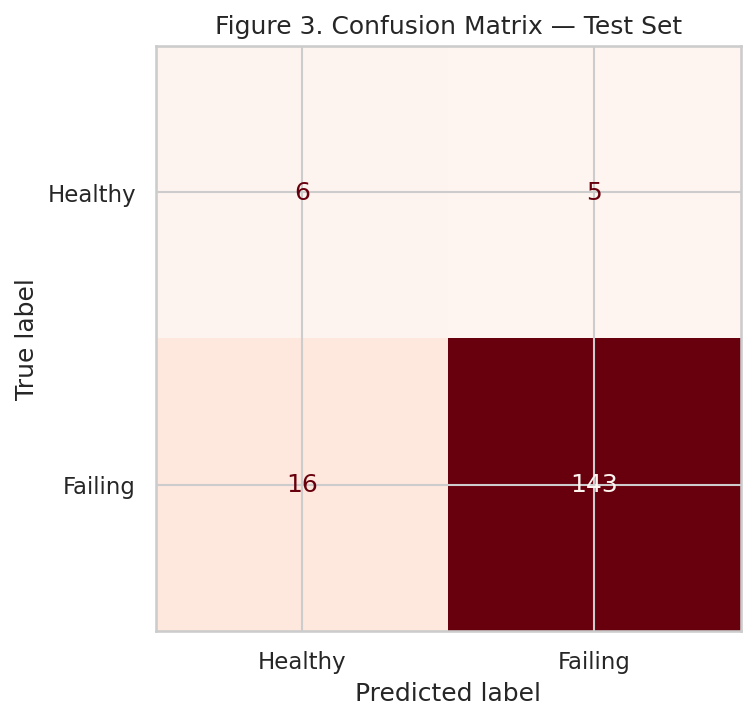

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy", "Failing"])
disp.plot(ax=ax, cmap="Reds", colorbar=False)
ax.set_title("Figure 3. Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()


### 3.1 Business implication

Sensitivity, not accuracy, is the metric that matters operationally here: it's the share of genuinely bad shifts the model successfully flags. Missing a bad shift (a false negative) means the crew runs the machine in a degraded state without warning — the exact failure mode this system exists to prevent. Flagging a healthy shift as at-risk (a false positive) mainly costs an unnecessary inspection, a far cheaper mistake than a missed one. Given that asymmetry, the model was trained with `class_weight="balanced"` to lean toward catching more real failures — which is also why its raw accuracy (87.6%) is *lower* than a trivial always-guess-"Failing" baseline (93.5%): that trade-off is deliberate, not a bug, but it needs to be explained to stakeholders rather than hidden behind a headline accuracy number.

Two honest limitations to flag rather than gloss over:

1. **Small "Healthy" sample.** Only 37 shifts in NBI-P03's history are labeled Healthy, so the specificity estimate (0.545) is based on a small test set and should be treated as provisional, not a firm production-ready number.
2. **Not yet a true leading indicator.** The voltage-based features (RMS, range) showed weak visual trends in Figure 2 and contribute less to the model than throughput-based features — meaning this prototype currently leans on the same throughput signal already used to find the problem in Week 5, rather than truly *predicting ahead of it*. A genuine early-warning system would need either a real vibration/pressure sensor feed, or evidence that voltage/temperature shifts *before* throughput drops, which this dataset does not clearly show. This is the top next step, and it's called out directly in the Technical Brief (Part B).
